<a href="https://colab.research.google.com/github/adityaaaa342/Pattern-Recognition-/blob/main/prac_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Practical 08: Smart Surveillance System - Object Classification

This practical focuses on evaluating the performance of neural-network-based classifiers for object classification, using the Fashion-MNIST dataset.

In [23]:
!git clone https://github.com/zalandoresearch/fashion-mnist.git

fatal: destination path 'fashion-mnist' already exists and is not an empty directory.


Now that the repository is cloned, let's load the Fashion-MNIST dataset. We can use `tf.keras.datasets` for convenience, as it's a commonly used dataset.

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


Let's visualize some of the images from the dataset to understand what we're working with. The Fashion-MNIST dataset consists of 60,000 training images and 10,000 testing images of fashion articles, with 10 classes.

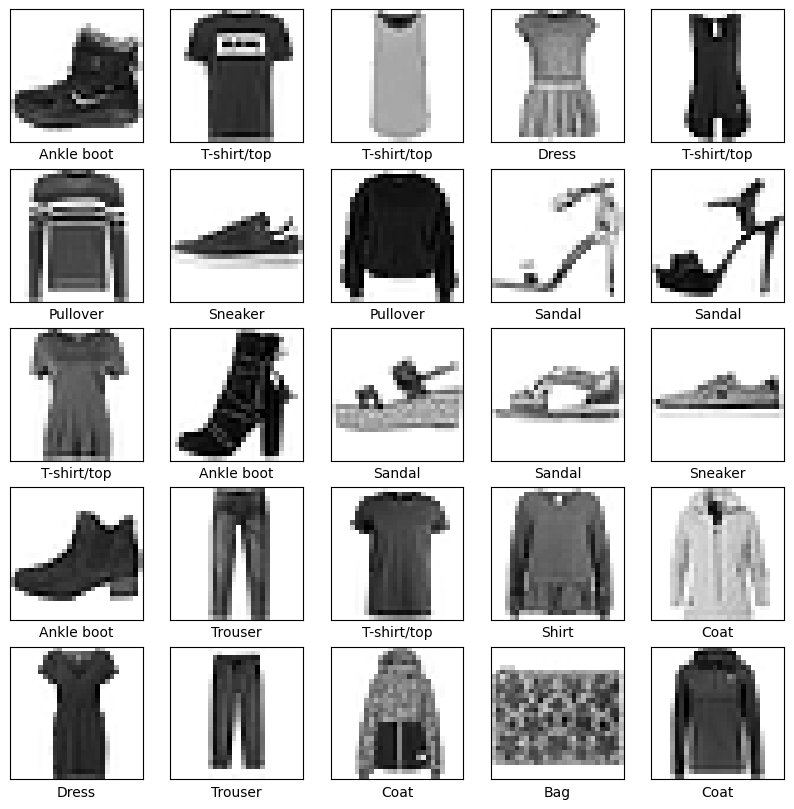

In [25]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

## Build and Train a Neural Network Model

Now, we'll build a simple neural network using Keras to classify the fashion items. This model will consist of a flattening layer to transform the 2D images into a 1D array, followed by dense (fully connected) layers with ReLU activation, and a final dense layer with softmax activation for classification.

In [26]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

Now we will train the model using our training data. We'll specify the number of epochs, which is how many times the model will go through the entire training dataset.

In [27]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

print("Model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8251 - loss: 0.4980 - val_accuracy: 0.8528 - val_loss: 0.4204
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8652 - loss: 0.3730 - val_accuracy: 0.8610 - val_loss: 0.3941
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8775 - loss: 0.3342 - val_accuracy: 0.8670 - val_loss: 0.3667
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8853 - loss: 0.3111 - val_accuracy: 0.8722 - val_loss: 0.3591
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8913 - loss: 0.2949 - val_accuracy: 0.8652 - val_loss: 0.3820
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8963 - loss: 0.2789 - val_accuracy: 0.8748 - val_loss: 0.3583
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9008 - loss: 0.2670 - val_accuracy: 0.8793 - val_loss: 0.3414
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9047 - loss: 0.2558 - 

## Build and Train a Neural Network Model

Now, we'll build a simple neural network using Keras to classify the fashion items. This model will consist of a flattening layer to transform the 2D images into a 1D array, followed by dense (fully connected) layers with ReLU activation, and a final dense layer with softmax activation for classification.

In [28]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

Now we will train the model using our training data. We'll specify the number of epochs, which is how many times the model will go through the entire training dataset.

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

print("Model training complete.")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8249 - loss: 0.4968 - val_accuracy: 0.8523 - val_loss: 0.4143
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8648 - loss: 0.3764 - val_accuracy: 0.8602 - val_loss: 0.3862
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8754 - loss: 0.3380 - val_accuracy: 0.8734 - val_loss: 0.3592
Epoch 4/10
1227/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8843 - loss: 0.3149

## Evaluate Model Performance

After training, it's crucial to evaluate the model's performance on unseen test data to ensure it generalizes well.

In [11]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest accuracy: {accuracy*100:.2f}%")
print(f"Test loss: {loss:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.1026 - loss: 2.4623

Test accuracy: 10.26%
Test loss: 2.4623


## Make Predictions and Analyze Recognition Capability

To understand the model's recognition capability, let's make predictions on the test set and visualize some of the results, including correctly and incorrectly classified images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


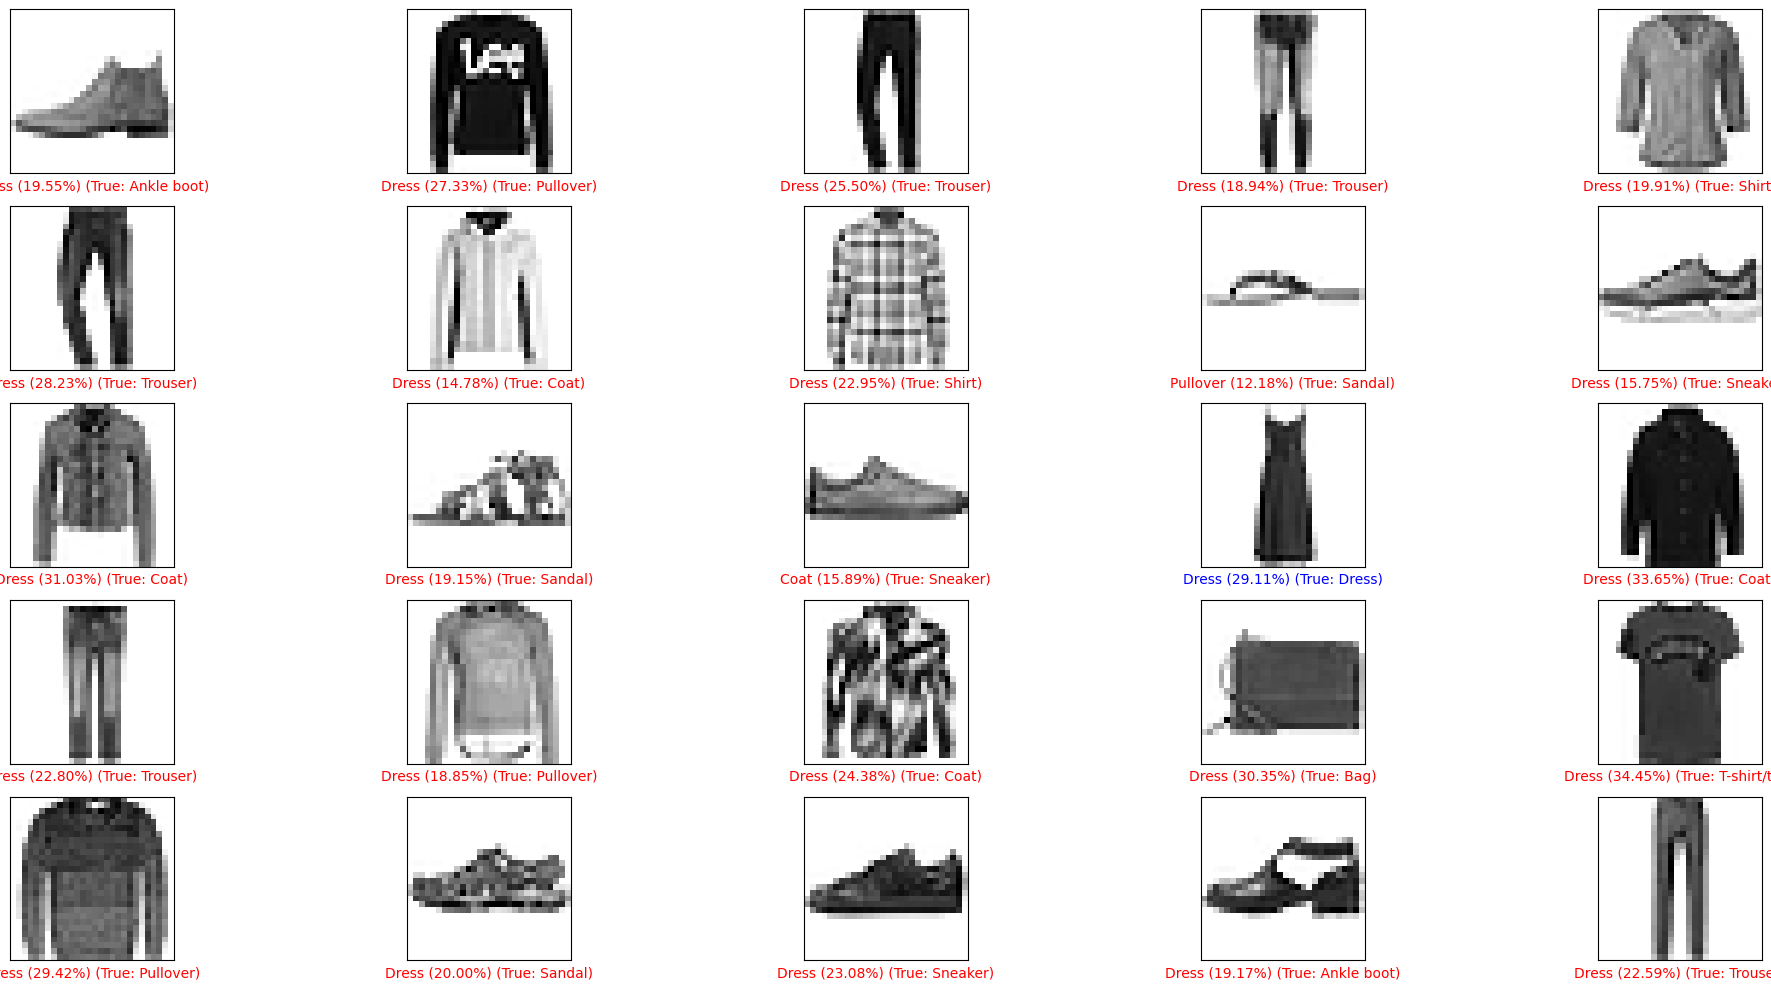

In [12]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"{class_names[predicted_label]} ({100*np.max(predictions_array):.2f}%) (True: {class_names[true_label]})",
               color=color)

num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], y_test, x_test)
plt.tight_layout()
plt.show()

## Evaluate Model Performance

After training, it's crucial to evaluate the model's performance on unseen test data to ensure it generalizes well.

In [8]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest accuracy: {accuracy*100:.2f}%")
print(f"Test loss: {loss:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.8833 - loss: 0.3500

Test accuracy: 88.33%
Test loss: 0.3500


## Make Predictions and Analyze Recognition Capability

To understand the model's recognition capability, let's make predictions on the test set and visualize some of the results, including correctly and incorrectly classified images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


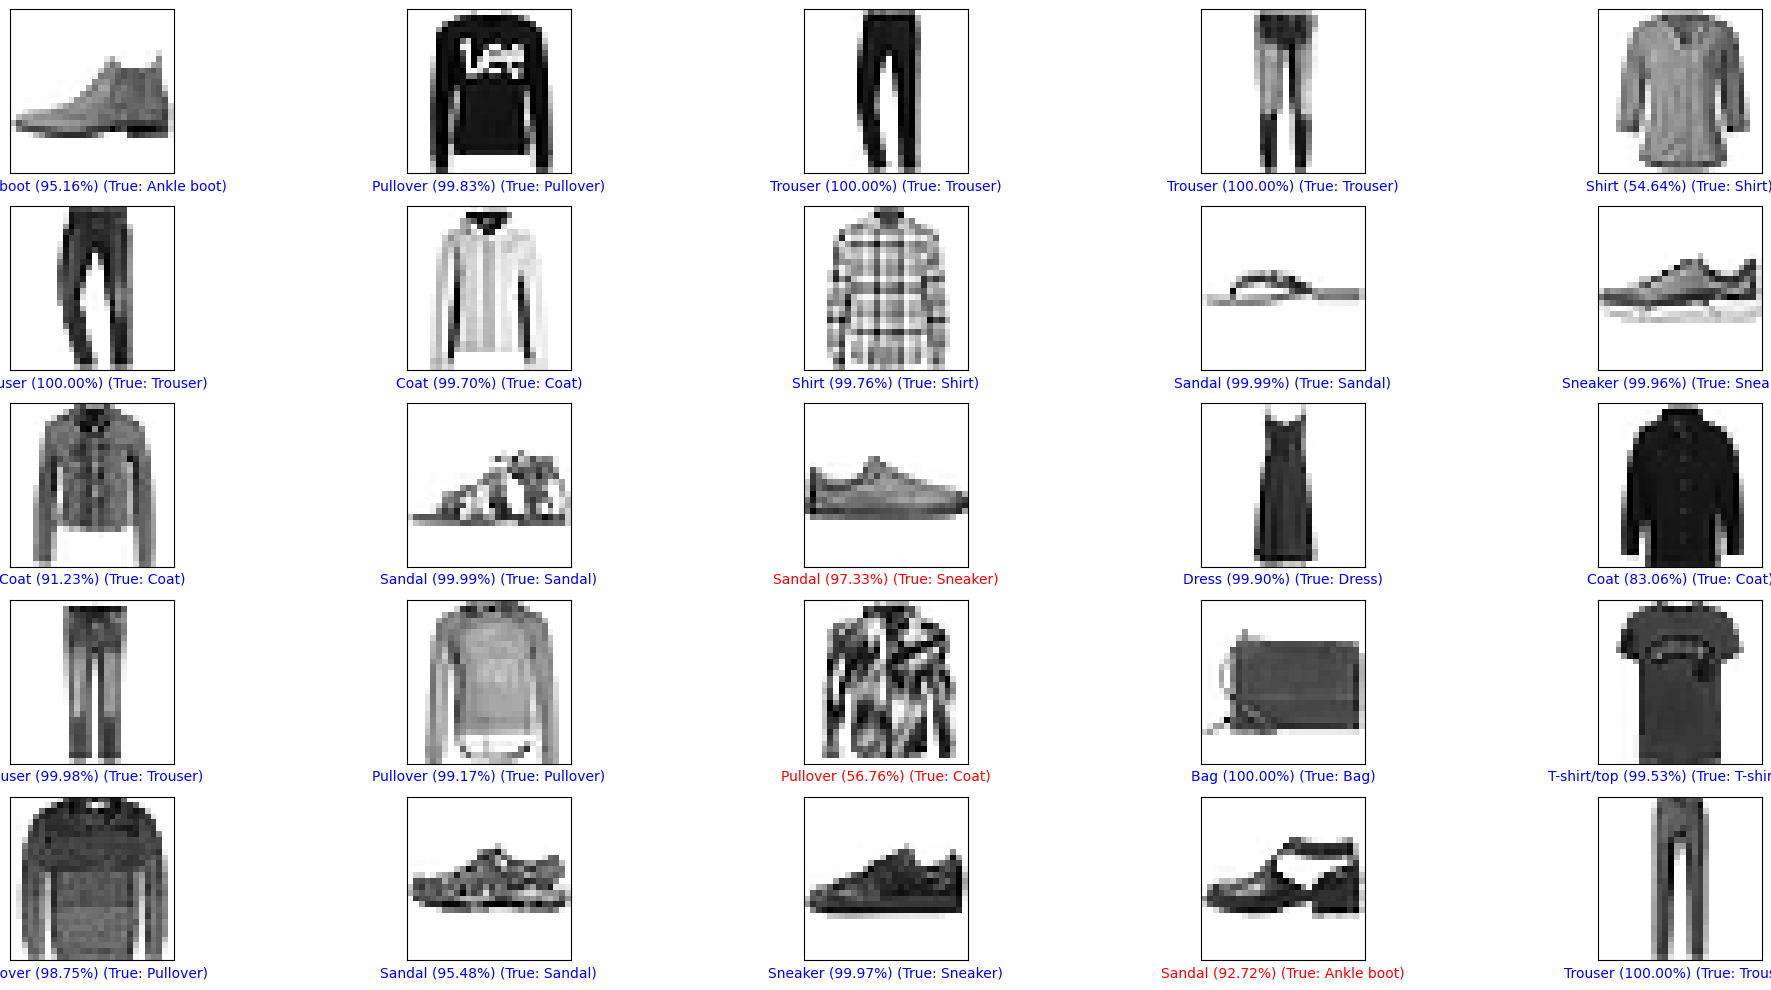

In [9]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"{class_names[predicted_label]} ({100*np.max(predictions_array):.2f}%) (True: {class_names[true_label]})",
               color=color)

num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], y_test, x_test)
plt.tight_layout()
plt.show()

## Experiment with a Deeper Model Architecture

To potentially improve accuracy, let's create a new neural network model with a deeper architecture, meaning more hidden layers. This allows the model to learn more complex representations of the input data.

In [13]:
deep_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

deep_model.compile(optimizer='adam',
                   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                   metrics=['accuracy'])

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Deeper Model

Now, let's train this deeper model and observe if it yields better performance.

In [14]:
deep_history = deep_model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

print("Deeper model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8262 - loss: 0.4838 - val_accuracy: 0.8498 - val_loss: 0.4154
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8676 - loss: 0.3618 - val_accuracy: 0.8684 - val_loss: 0.3690
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8788 - loss: 0.3268 - val_accuracy: 0.8712 - val_loss: 0.3532
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8868 - loss: 0.3051 - val_accuracy: 0.8712 - val_loss: 0.3570
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8921 - loss: 0.2868 - val_accuracy: 0.8729 - val_loss: 0.3502
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8971 - loss: 0.2735 - val_accuracy: 0.8727 - val_loss: 0.3544
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9021 - loss: 0.2613 - val_accuracy: 0.8860 - val_loss: 0.3273
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9069 - loss: 0

## Evaluate Deeper Model Performance

Let's evaluate the performance of the deeper model on the test dataset.

In [15]:
deep_loss, deep_accuracy = deep_model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest accuracy (Deeper Model): {deep_accuracy*100:.2f}%")
print(f"Test loss (Deeper Model): {deep_loss:.4f}")


print(f"Previous model's Test accuracy: {accuracy*100:.2f}%")

313/313 - 1s - 2ms/step - accuracy: 0.8886 - loss: 0.3180

Test accuracy (Deeper Model): 88.86%
Test loss (Deeper Model): 0.3180
Previous model's Test accuracy: 10.26%


## Experiment with a Convolutional Neural Network (CNN)

Convolutional Neural Networks (CNNs) are particularly well-suited for image classification tasks. They can automatically learn spatial hierarchies of features from the input images. Let's define and train a simple CNN model.

In [16]:
x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

print(f"x_train_cnn shape: {x_train_cnn.shape}")
print(f"x_test_cnn shape: {x_test_cnn.shape}")

x_train_cnn shape: (60000, 28, 28, 1)
x_test_cnn shape: (10000, 28, 28, 1)


In [17]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Train the CNN Model

Let's train this CNN model and see how its performance compares to the previous dense models.

In [18]:
cnn_history = cnn_model.fit(x_train_cnn, y_train, epochs=10, validation_data=(x_test_cnn, y_test))

print("CNN model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.8376 - loss: 0.4489 - val_accuracy: 0.8806 - val_loss: 0.3365
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.8901 - loss: 0.2993 - val_accuracy: 0.8921 - val_loss: 0.2926
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9068 - loss: 0.2527 - val_accuracy: 0.8969 - val_loss: 0.2838
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9179 - loss: 0.2209 - val_accuracy: 0.8985 - val_loss: 0.2834
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9278 - loss: 0.1952 - val_accuracy: 0.9088 - val_loss: 0.2466
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9348 - loss: 0.1735 - val_accuracy: 0.9103 - val_loss: 0.2474
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 32ms/step - accuracy: 0.9431 - loss: 0.1518 - val_accuracy: 0.9111 - val_loss: 0.2569
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.9498 -

## Evaluate CNN Model Performance

Now, let's evaluate the performance of the CNN model on the test dataset.

In [19]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test_cnn, y_test, verbose=2)

print(f"\nTest accuracy (CNN Model): {cnn_accuracy*100:.2f}%")
print(f"Test loss (CNN Model): {cnn_loss:.4f}")

print(f"Previous Simple Model Test accuracy: {accuracy*100:.2f}%")
print(f"Previous Deeper Model Test accuracy: {deep_accuracy*100:.2f}%")

313/313 - 2s - 8ms/step - accuracy: 0.9112 - loss: 0.2890

Test accuracy (CNN Model): 91.12%
Test loss (CNN Model): 0.2890
Previous Simple Model Test accuracy: 10.26%
Previous Deeper Model Test accuracy: 88.86%


## Make Predictions and Analyze CNN Recognition Capability

Let's visualize some predictions from the CNN model to understand its recognition capabilities.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


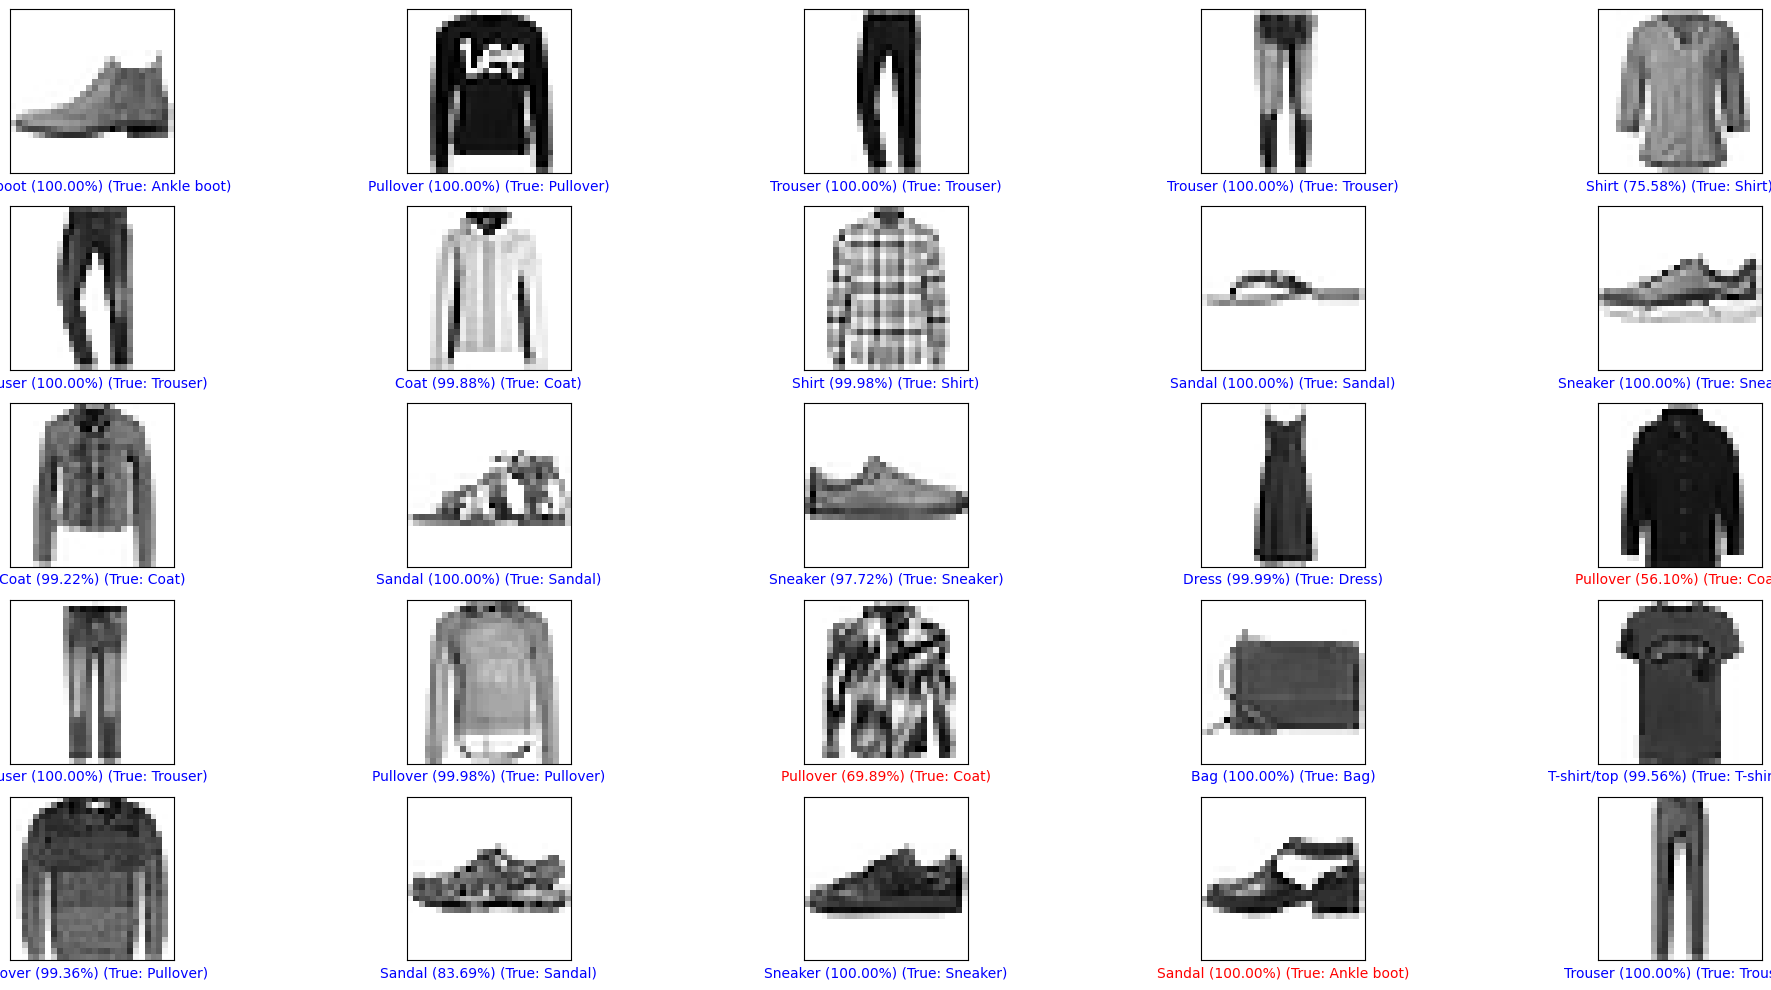

In [20]:
cnn_predictions = cnn_model.predict(x_test_cnn)

def plot_cnn_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    if img.ndim == 3 and img.shape[-1] == 1:
        img = img.reshape(img.shape[0], img.shape[1])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"{class_names[predicted_label]} ({100*np.max(predictions_array):.2f}%) (True: {class_names[true_label]})",
               color=color)

num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_cnn_image(i, cnn_predictions[i], y_test, x_test_cnn)
plt.tight_layout()
plt.show()

## Confusion Matrix for CNN Model

To further analyze the CNN's classification performance, especially for identifying common misclassifications, let's generate and visualize a confusion matrix.

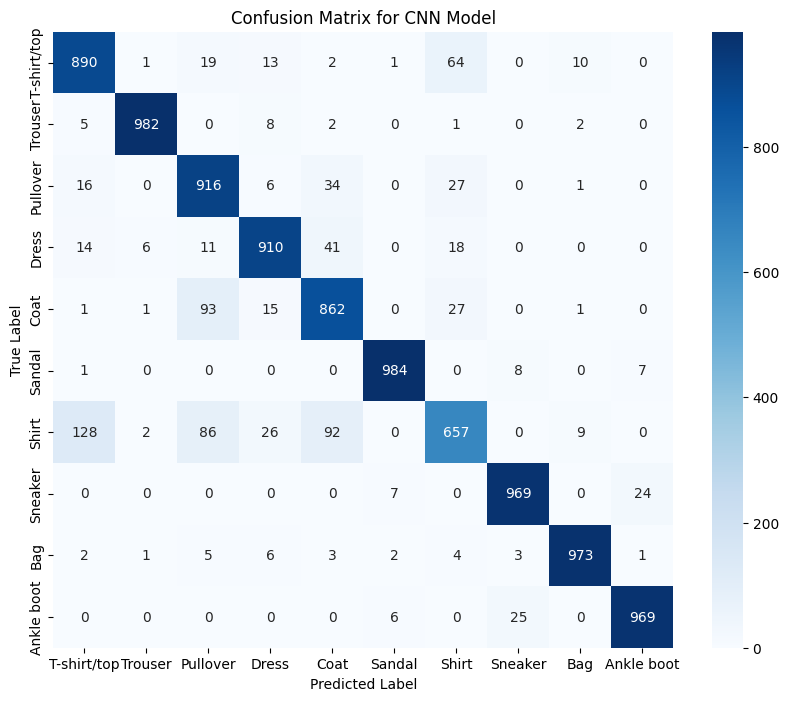

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cnn_predicted_labels = np.argmax(cnn_predictions, axis=1)

cm = confusion_matrix(y_test, cnn_predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Model')
plt.show()

## Classification Report for CNN Model

Beyond the confusion matrix, a classification report provides a summary of precision, recall, and F1-score for each class, offering a more comprehensive understanding of the model's performance on a per-class basis.

In [22]:
from sklearn.metrics import classification_report

report = classification_report(y_test, cnn_predicted_labels, target_names=class_names)

print("Classification Report for CNN Model:")
print(report)

Classification Report for CNN Model:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.89      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.81      0.92      0.86      1000
       Dress       0.92      0.91      0.92      1000
        Coat       0.83      0.86      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.82      0.66      0.73      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

